<a href="https://colab.research.google.com/github/aidenjbrown/Intermediate_Data_Science_CS_28/blob/main/scripts/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. What is your outcome variable(s)? How well does it measure the outcome you are interested? How does it
relate to your expectations?

Our outcome variable is depression score. It measures the outcome we are interested in very well because it is the exact criteria the CDC uses to estimate the prevalance of depression across the population.

2. What are your key explanatory variables?

Our key explanatory variables are...

3. What data cleaning did you have to do?

We had to clean the data by dropping any observation with na !!!

4. How did you wrangle the data?

We wrangled the data by performing an inner merge on all of the 4 raw datasets by SEQN number. We also dropped all of the variables we did not need from the raw data by choosing to only keep the subset that we did need.

5. Are you deciding to exclude any observations? If so, why?

We are deciding to exclude any observations that have...

6. Did you have to create any new variables from existing variables? If so, how and why?

We did have to create the depression score variable because it was not calculated for us. So if the answer to each question related to depression symptoms had between a 0 and 3 as a response, we recorded added it to the other responses for the same participant for all the depression symptoms to get a score with the max being 27. We wanted to create this variable so we could determine if certain predictors were associated with depression more broadly rather than invidual symptoms only.

In [24]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [32]:
# Importing the data

# from google.colab import drive
# drive.mount('/content/drive')
import pandas as pd

# depression = pd.read_sas('/content/drive/MyDrive/DataScienceXPTFiles/DPQ_J.xpt')
# depression.to_csv('/content/drive/MyDrive/DataScienceXPTFiles/Depression_Scores.csv', index=False)

# income = pd.read_sas('/content/drive/MyDrive/DataScienceXPTFiles/INQ_J.xpt')
# income.to_csv('/content/drive/MyDrive/DataScienceXPTFiles/Income.csv', index=False)

# demographics = pd.read_sas('/content/drive/MyDrive/DataScienceXPTFiles/DEMO_J.xpt')
# demographics.to_csv('/content/drive/MyDrive/DataScienceXPTFiles/Demographics.csv', index=False)

# sleep = pd.read_sas('/content/drive/MyDrive/DataScienceXPTFiles/SLQ_J.xpt')
# sleep.to_csv('/content/drive/MyDrive/DataScienceXPTFiles/Sleep.csv', index=False)

depression = pd.read_sas('../data/DPQ_J.xpt')
depression.to_csv('../data/Depression_Scores.csv', index=False)

income = pd.read_sas('../data/INQ_J.xpt')
income.to_csv('../data/Income.csv', index=False)

demographics = pd.read_sas('../data/DEMO_J.xpt')
demographics.to_csv('../data/Demographics.csv', index=False)

sleep = pd.read_sas('../data/SLQ_J.xpt')
sleep.to_csv('../data/Sleep.csv', index=False)

occupation = pd.read_sas('../data/OCQ_J.xpt')
occupation.to_csv('../data/Occupation.csv', index=False)


In [26]:
# Now we will merge all of the data based on the SEQN number. Using inner merge to make sure the SEQN exists in both datasets.

merge1 = pd.merge(depression, income, on='SEQN', how = "inner")
print(merge1.shape)
merge2 = pd.merge(merge1, demographics, on='SEQN', how = "inner")
print(merge2.shape)
df = pd.merge(merge2, sleep, on='SEQN', how = "inner").merge(occupation, on='SEQN', how = "inner")
print(df.shape)


# Now we want to determine what explanatory variables we are going to keep.




(5533, 26)
(5533, 71)
(5533, 90)


In [27]:
# First we are going to get rid of any response for the depression indicators that weren't 0-3, in other words, the responses that did not mention whether
# or how often they were feeling this way. We are ignoring the variable (DPQ100) that asks about the difficulty the problems have causec because it is
# not directly related to depression score and uses a different encoding system.

depression_cols = ["DPQ010", "DPQ020", "DPQ030", "DPQ040", "DPQ050", "DPQ060", "DPQ070", "DPQ080", "DPQ090"]


# Using a Lamda expression here so we can get the data we want (between 0 and 3) for each collumn at a time
df[depression_cols] = df[depression_cols].apply(lambda x: x.where(x.between(0, 3)))

df["depression_score"] = df[depression_cols].sum(axis=1)
df

,SEQN,DPQ010,DPQ020,DPQ030,DPQ040,DPQ050,DPQ060,DPQ070,DPQ080,DPQ090,...,OCD150,OCQ180,OCQ210,OCQ260,OCD270,OCQ670,OCQ380,OCD390G,OCD395,depression_score
0,93705.0,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,...,1.0,30.0,1.0,1.0,36.0,5.0,NaN,2.0,NaN,4.857845e-78
1,93706.0,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,...,4.0,NaN,NaN,NaN,NaN,NaN,2.0,4.0,NaN,4.857845e-78
2,93708.0,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,...,4.0,NaN,NaN,NaN,NaN,NaN,4.0,1.0,180.0,4.857845e-78
3,93709.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.0,NaN,NaN,NaN,NaN,NaN,6.0,1.0,360.0,0.000000e+00
4,93711.0,1.000000e+00,5.397605e-79,1.000000e+00,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,...,1.0,35.0,NaN,4.0,24.0,1.0,NaN,2.0,NaN,2.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5528,102949.0,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,...,1.0,80.0,NaN,5.0,60.0,5.0,NaN,2.0,NaN,4.857845e-78
5529,102952.0,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,...,4.0,NaN,NaN,NaN,NaN,NaN,3.0,1.0,168.0,4.857845e-78
5530,102953.0,1.000000e+00,1.000000e+00,5.397605e-79,1.000000e+00,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,...,1.0,42.0,NaN,1.0,204.0,5.0,NaN,1.0,216.0,3.000000e+00
5531,102954.0,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,...,3.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,120.0,4.857845e-78


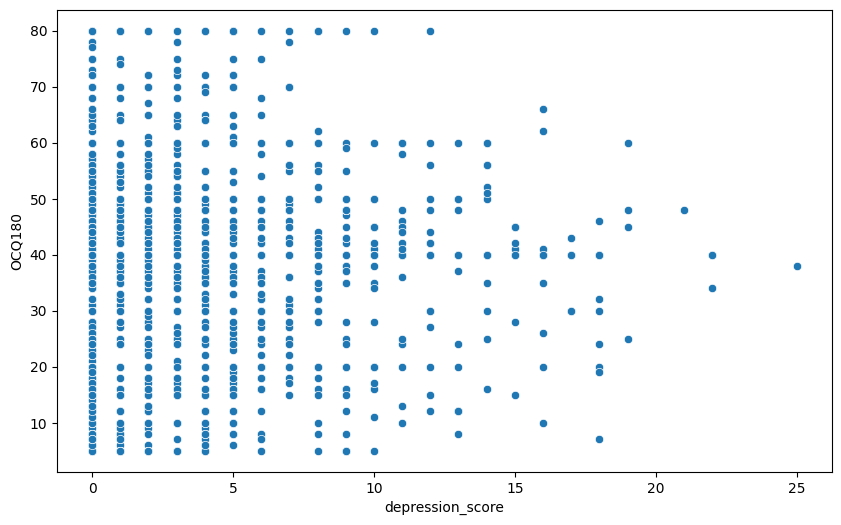

In [33]:
# making visualizations
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df['OCQ180'] = df['OCQ180'].replace([77777, 99999,'.'], np.nan)
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df, x="depression_score", y="OCQ180", ax=ax)

plt.show()
